In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

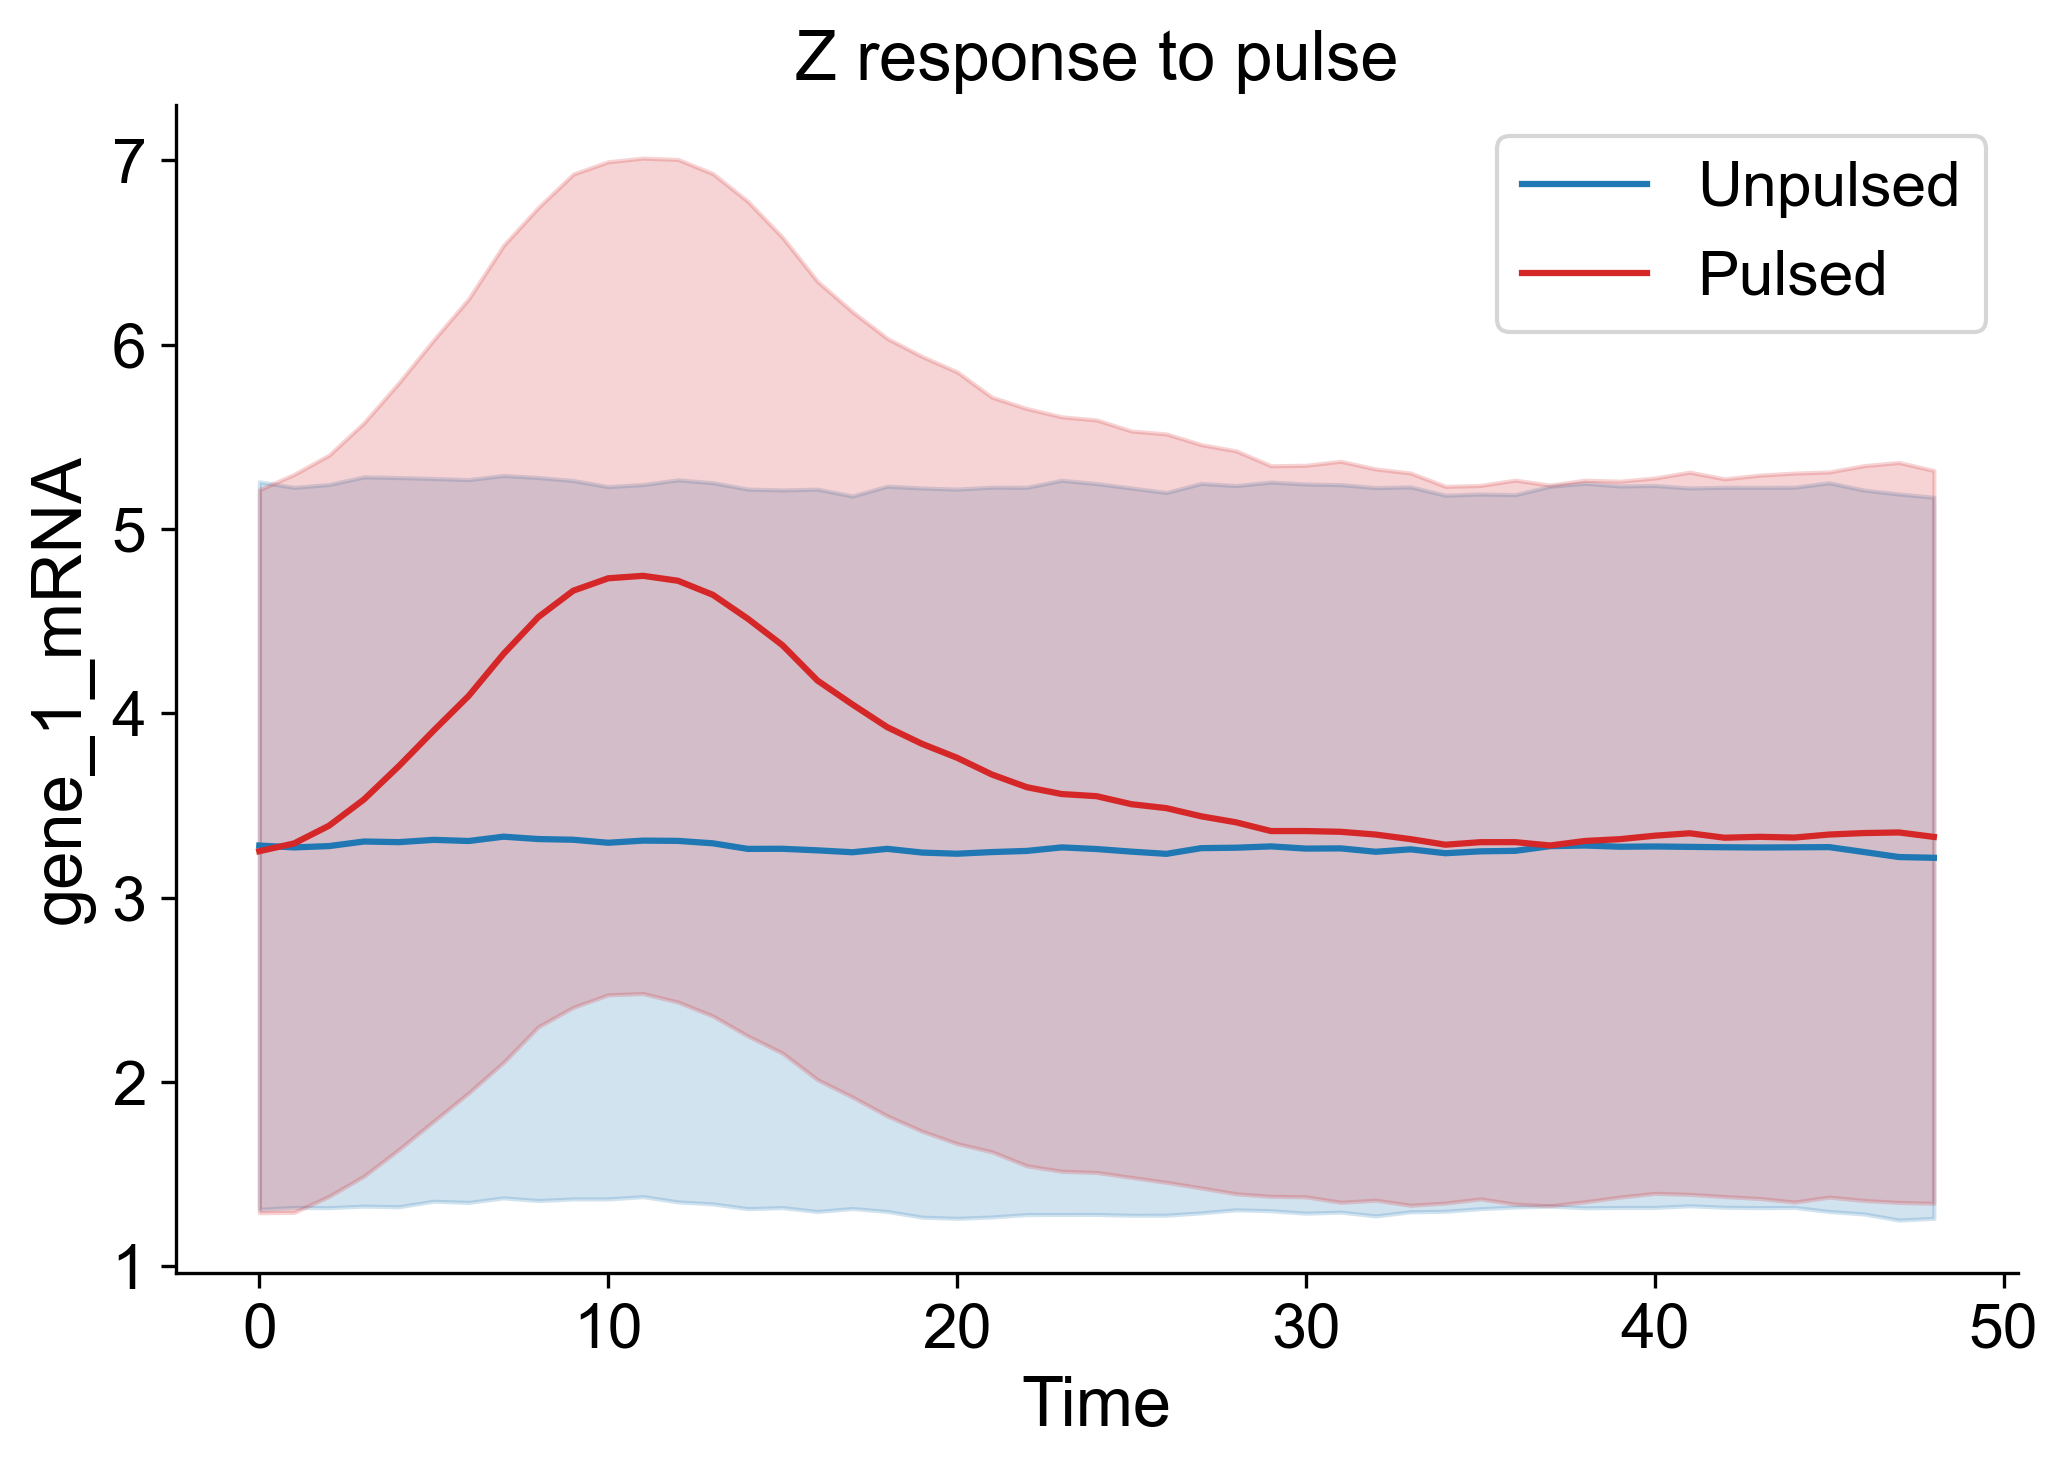

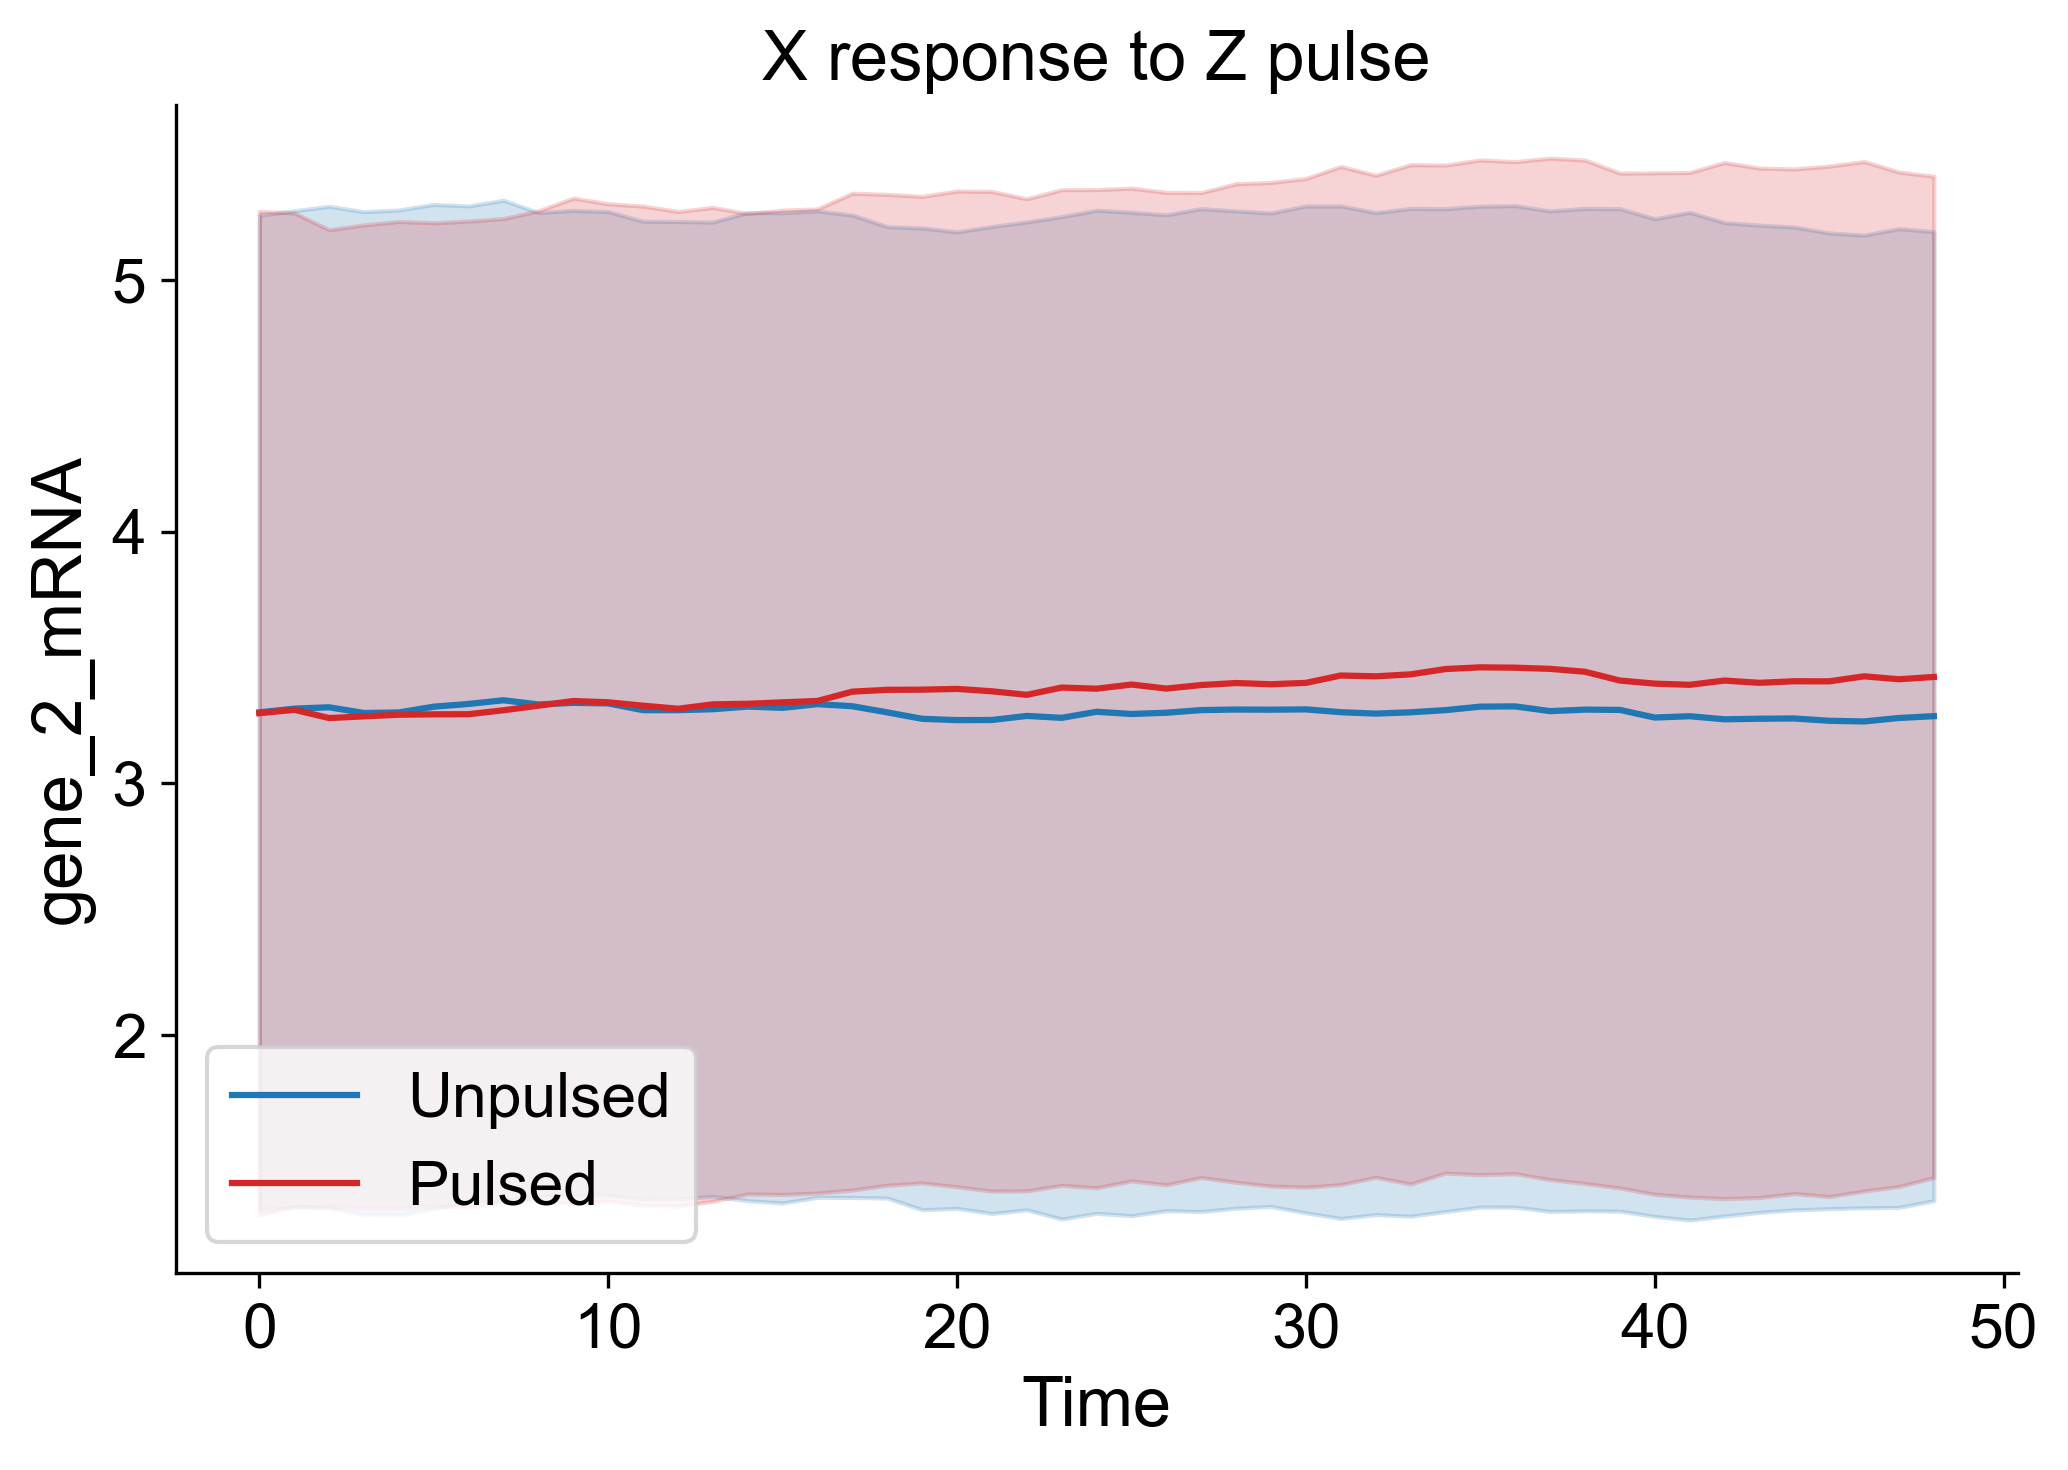

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_std(
    df_base,
    df_pulse,
    gene,
    time_col="time_step",
    cell_col="cell_id",
    title=None
):

    # --- Compute mean and std across cells ---
    base_mean = df_base.groupby(time_col)[gene].mean()
    base_std  = df_base.groupby(time_col)[gene].std()

    pulse_mean = df_pulse.groupby(time_col)[gene].mean()
    pulse_std  = df_pulse.groupby(time_col)[gene].std()

    # Align times
    base_mean, pulse_mean = base_mean.align(pulse_mean, join="inner")
    base_std, pulse_std   = base_std.align(pulse_std, join="inner")

    t = base_mean.index.values

    # --- Plot ---
    plt.figure(figsize=(7,5))

    # Unpulsed
    plt.plot(t, base_mean, label="Unpulsed", color="#1f77b4")
    plt.fill_between(t,
                     base_mean - base_std,
                     base_mean + base_std,
                     color="#1f77b4",
                     alpha=0.2)

    # Pulsed
    plt.plot(t, pulse_mean, label="Pulsed", color="#d62728")
    plt.fill_between(t,
                     pulse_mean - pulse_std,
                     pulse_mean + pulse_std,
                     color="#d62728",
                     alpha=0.2)

    plt.xlabel("Time")
    plt.ylabel(gene)
    if title:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/pulse_three_gene_motif_longer_pulse/A_and_B/df_rows_0_0_1_20022026_010953_ncells_6000_A_and_B_497b4cb3.csv")
df_base = df[df['state'] == "down"]
df_pulse = df[df['state'] == "up"]
plot_mean_std(df_base, df_pulse, "gene_1_mRNA",
              title="Z response to pulse")

plot_mean_std(df_base, df_pulse, "gene_2_mRNA",
              title="X response to Z pulse")


A_to_B: 27 files found
A_and_B: 6 files found
fan_in: 27 files found
regulated_mutual: 27 files found
feed_forward: 27 files found
fan_out: 27 files found


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


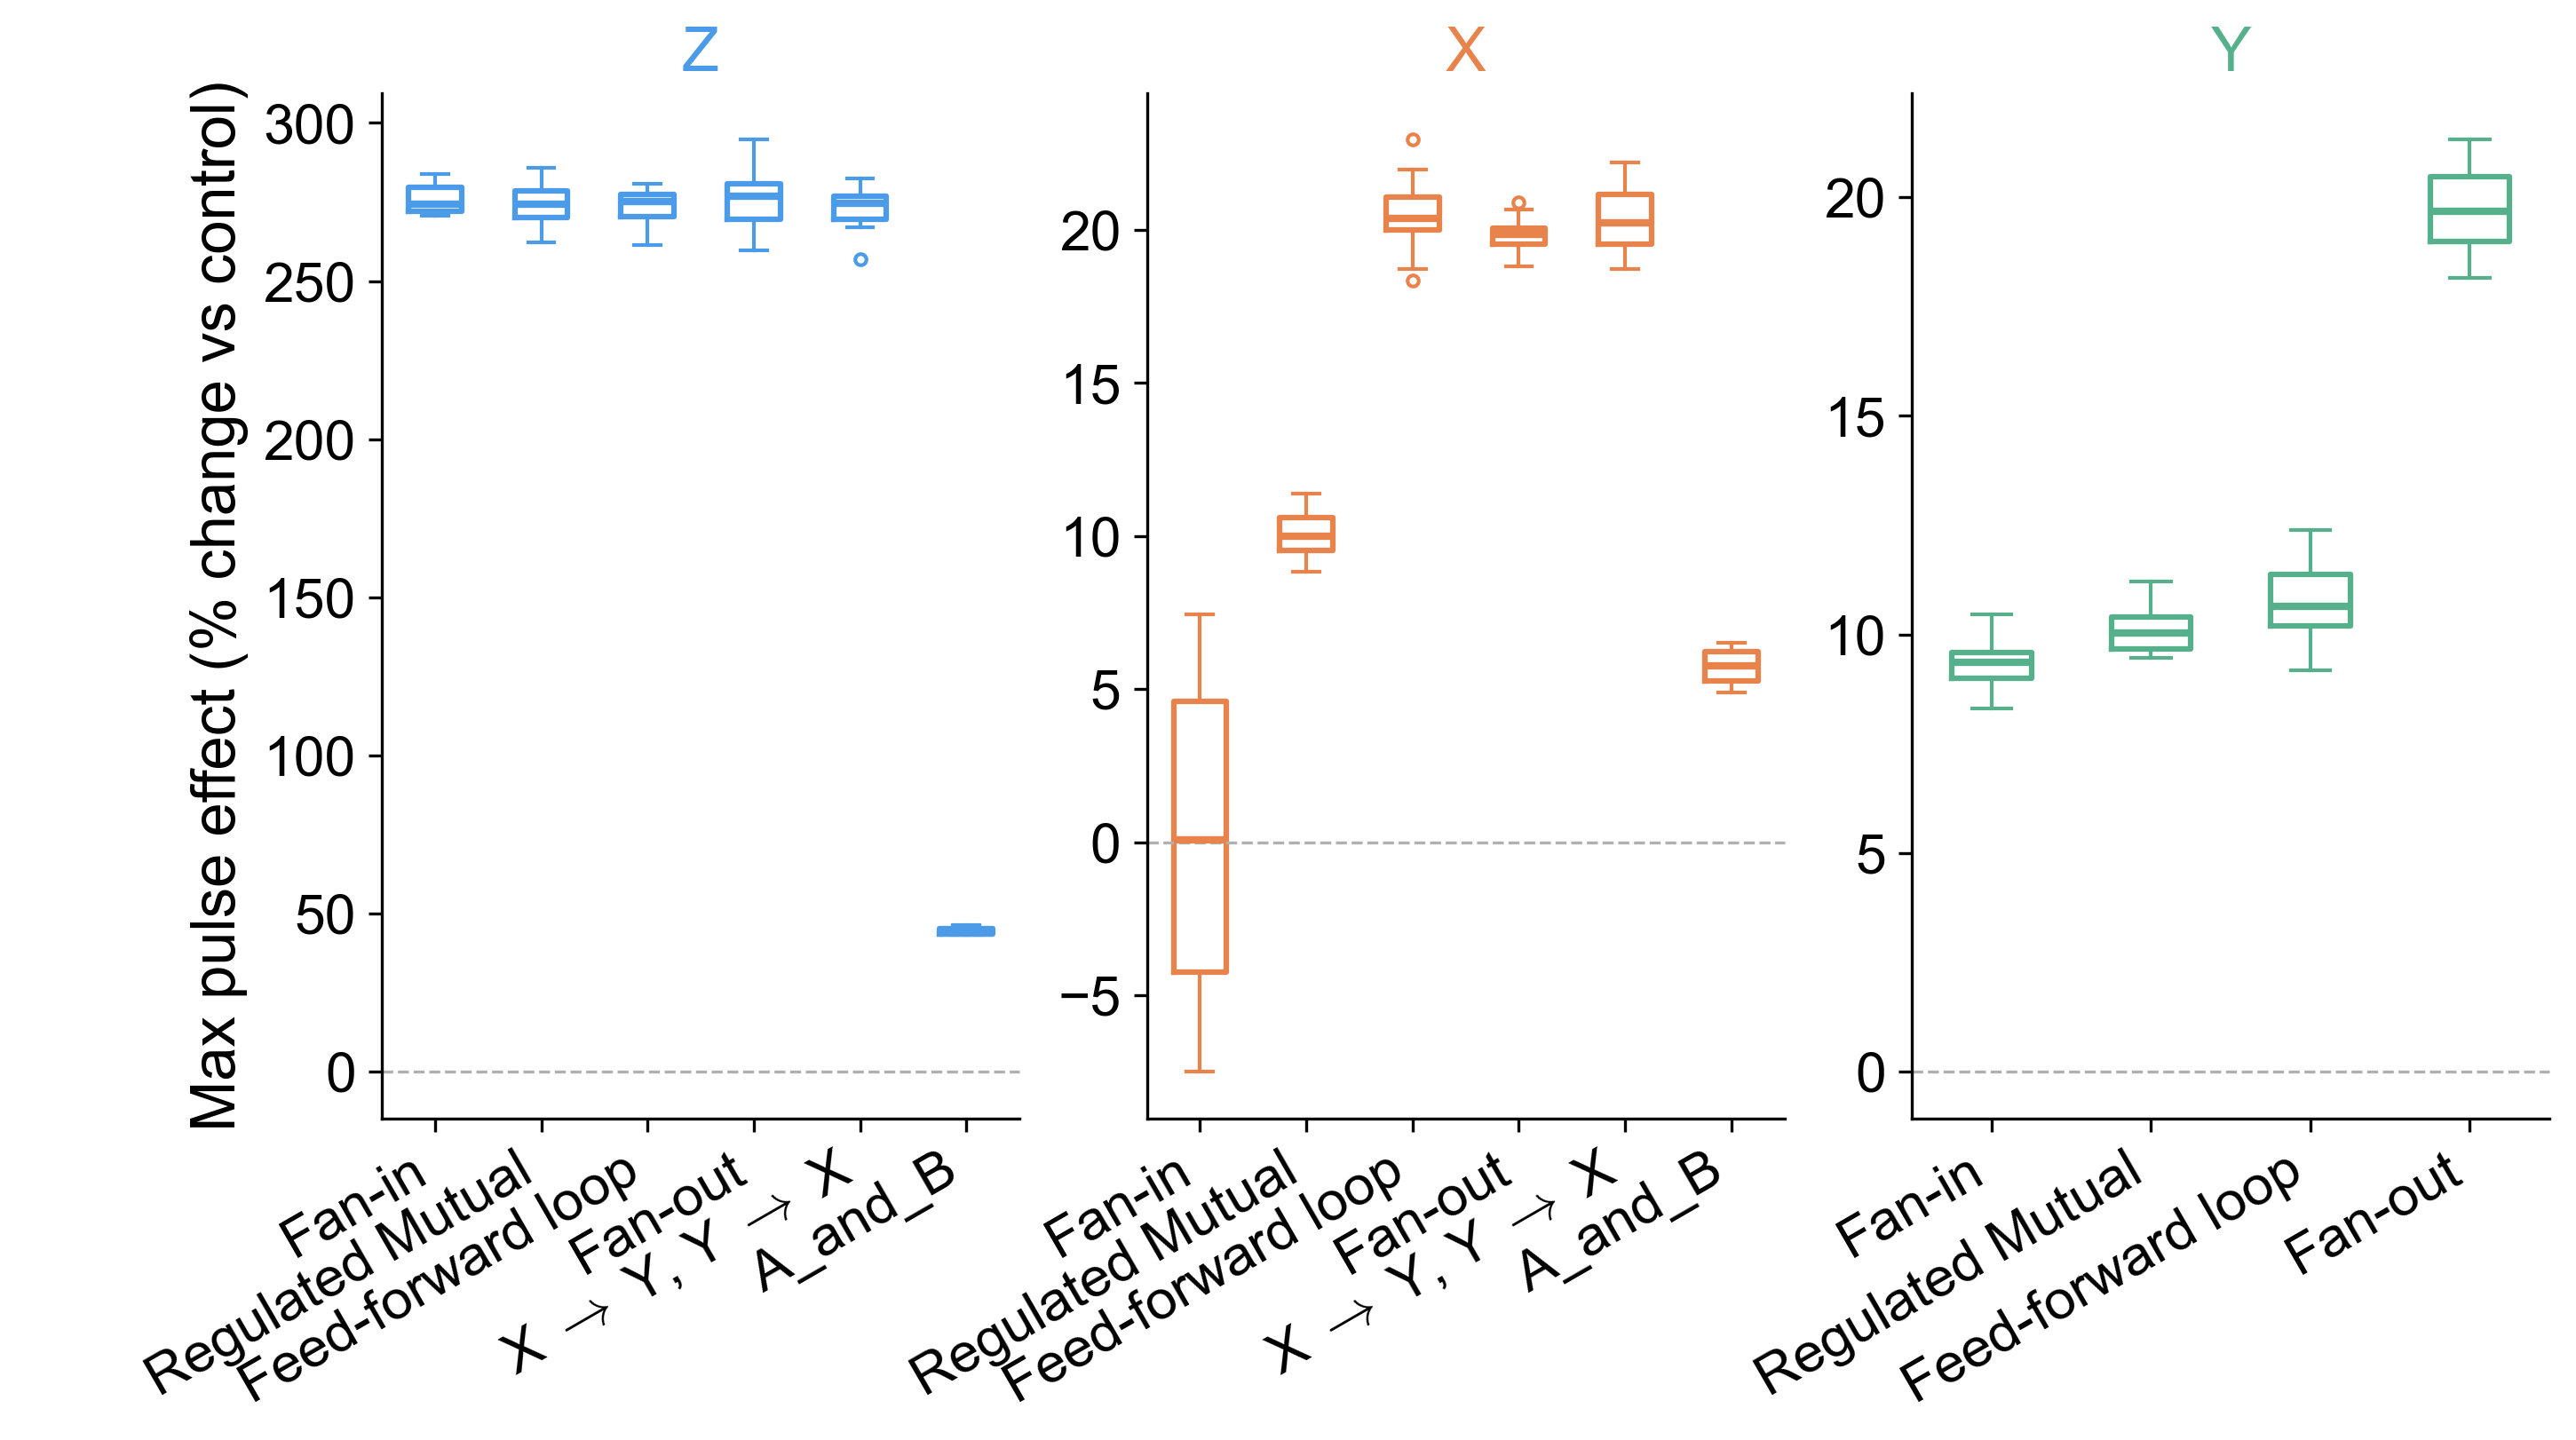

In [173]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/pulse_three_gene_motif_longer_pulse"

motif_patterns = {
    "A_to_B":           f"{BASE_DIR}/A_to_B/df_rows_0_0_*_ncells_6000_A_to_B_*.csv",
    "A_and_B":          f"{BASE_DIR}/A_and_B/df_rows_0_0_*_ncells_6000_A_and_B_*.csv",
    "fan_in":           f"{BASE_DIR}/fan_in/df_rows_0_0_0_*_ncells_6000_fan_in_*.csv",
    "regulated_mutual": f"{BASE_DIR}/regulated_mutual/df_rows_0_0_0_*_ncells_6000_regulated_mutual_*.csv",
    "feed_forward":     f"{BASE_DIR}/feed_forward/df_rows_0_0_0_*_ncells_6000_feed_forward_*.csv",
    "fan_out":          f"{BASE_DIR}/fan_out/df_rows_0_0_0_*_ncells_6000_fan_out_*.csv",
}

MOTIF_DISPLAY_NAMES = {
    "A_to_B":           r"X $\rightarrow$ Y",
    "A_to_B":           r"X $\rightarrow$ Y, Y $\rightarrow$ X",
    "fan_in":           "Fan-in",
    "fan_out":          "Fan-out",
    "feed_forward":     "Feed-forward loop",
    "regulated_mutual": "Regulated Mutual",
}

GENE_DISPLAY_NAMES = {
    "gene_1_mRNA": "Z",
    "gene_2_mRNA": "X",
    "gene_3_mRNA": "Y",
    "gene_1_protein": "Z protein",
    "gene_2_protein": "X protein",
    "gene_3_protein": "Y protein",
}

# Subtle, distinct, non-grey colors — one per gene
GENE_COLORS = {
    "gene_1_mRNA":    "#4C9BE8",   # soft blue  — Z
    "gene_2_mRNA":    "#E8834C",   # soft orange — X
    "gene_3_mRNA":    "#56B08B",   # soft teal  — Y
    "gene_1_protein": "#4C9BE8",
    "gene_2_protein": "#E8834C",
    "gene_3_protein": "#56B08B",
}

genes_1 = ["gene_1_mRNA", "gene_2_mRNA", "gene_3_mRNA"]
genes_2 = ["gene_1_mRNA", "gene_2_mRNA"]
time_col = "time_step"

def compute_max_pulse(df_base, df_pulse, gene, time_col="time_step"):
    t = np.array(sorted(df_base[time_col].unique()))
    base_mean  = df_base.groupby(time_col)[gene].mean().reindex(t)
    pulse_mean = df_pulse.groupby(time_col)[gene].mean().reindex(t)
    pct_change = ((pulse_mean - base_mean) / base_mean) * 100
    idx = pct_change.abs().idxmax()
    return pct_change[idx]

# --- Collect results ---
results = {motif: {gene: [] for gene in genes_1} for motif in motif_patterns}

for motif, pattern in motif_patterns.items():
    genes = genes_2 if motif in["A_to_B", "A_and_B"] else genes_1
    files = sorted(glob.glob(pattern))
    print(f"{motif}: {len(files)} files found")
    for f in files[:20]:
        df = pd.read_csv(f)
        df_base  = df[df['state'] == "down"].copy()
        df_pulse = df[df['state'] == "up"].copy()
        for gene in genes:
            try:
                results[motif][gene].append(
                    compute_max_pulse(df_base, df_pulse, gene, time_col)
                )
            except Exception as e:
                print(f"  Skipping {f} / {gene}: {e}")

# --- Plot: one subplot per motif, one box per gene ---
motifs_ordered = [m for m in motif_patterns if m not in  ["A_to_B", "A_and_B"]] + ["A_to_B", "A_and_B"]
n_motifs = len(motifs_ordered)

genes_all = genes_1  # all 3 genes as subplots

fig, axes = plt.subplots(1, len(genes_all), figsize=(3.5 * len(genes_all), 5),
                         sharey=False, constrained_layout=True)

for ax, gene in zip(axes, genes_all):
    color = GENE_COLORS[gene]

    # only motifs that have this gene
    motifs_to_plot = [m for m in motifs_ordered
                      if gene in (genes_2 if m in ["A_to_B", "A_and_B"] else genes_1)]

    data = [results[motif][gene] for motif in motifs_to_plot]
    n_boxes = len(motifs_to_plot)

    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=False,
        medianprops=dict(linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        flierprops=dict(marker="o", markerfacecolor="none", markersize=3),
    )

    for i, (box, w1, w2, c1, c2, flier, median) in enumerate(zip(
        bp["boxes"],
        bp["whiskers"][0::2], bp["whiskers"][1::2],
        bp["caps"][0::2],     bp["caps"][1::2],
        bp["fliers"],
        bp["medians"],
    )):
        box.set_color(color)
        w1.set_color(color);  w2.set_color(color)
        c1.set_color(color);  c2.set_color(color)
        flier.set_markeredgecolor(color)
        median.set_color(color)

    ax.set_xticks(np.arange(1, n_boxes + 1))
    ax.set_xticklabels(
        [MOTIF_DISPLAY_NAMES.get(m, m) for m in motifs_to_plot],
        rotation=30, ha="right"
    )
    ax.set_title(GENE_DISPLAY_NAMES.get(gene, gene), color=color)
    ax.axhline(0, color="#B0B0B0", linewidth=0.8, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for artist in ax.get_children():
        artist.set_clip_on(False)
    ax.set_clip_on(False)

axes[0].set_ylabel("Max pulse effect (% change vs control)")
plt.show()

# Comparing the cross-correlation at different times

In [83]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

In [172]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Paths & patterns
# ============================================================
BASE_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/"

motif_patterns = {
    "A_to_B":           f"{BASE_DIR}/A_to_B/df_rows_0_0_*_ncells_6000_A_to_B_k_add_6*.csv",
    "A_and_B":          f"{BASE_DIR}/A_and_B/df_rows_0_0_*_ncells_6000_A_and_B_k_add_6*.csv",
    "fan_in":           f"{BASE_DIR}/fan_in/df_rows_0_0_0_*_ncells_6000_fan_in_k_add_6*.csv",
    "fan_out":          f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/df_rows_0_0_0_*_ncells_6000_Fan_out_additive_*.csv",
    "feed_forward":     f"{BASE_DIR}/feed_forward/df_rows_0_0_0_*_ncells_6000_feed_forward_k_add_6*.csv",
    "regulated_mutual": f"{BASE_DIR}/mutual_regulation/df_rows_0_0_0_*_ncells_6000_mutual_regulation_k_add_6*.csv",
}

MOTIF_FILES = {
    motif: sorted(glob.glob(pattern))[:20]
    for motif, pattern in motif_patterns.items()
}
for motif, files in MOTIF_FILES.items():
    print(f"{motif}: {len(files)} files found")

# ============================================================
# Gene columns
# ============================================================
time_col = "time_step"

TWO_GENE_CONFIG = {
    "y_col":       "gene_1_mRNA",
    "x1_col":      "gene_2_mRNA",
    "x2_col":      None,
    "gene_labels": {"gene_1_mRNA": "X", "gene_2_mRNA": "Y"},
    "pair_order":  [("gene_1_mRNA", "gene_2_mRNA")],
    "pair_labels": {("gene_1_mRNA", "gene_2_mRNA"): "X-Y"},
    "metrics":     ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"],
}

THREE_GENE_CONFIG = {
    "y_col":       "gene_1_mRNA",
    "x1_col":      "gene_2_mRNA",
    "x2_col":      "gene_3_mRNA",
    "gene_labels": {"gene_1_mRNA": "Z", "gene_2_mRNA": "X", "gene_3_mRNA": "Y"},
    "pair_order":  [
        ("gene_2_mRNA", "gene_3_mRNA"),   # X-Y
        ("gene_1_mRNA", "gene_3_mRNA"),   # Z-Y
        ("gene_1_mRNA", "gene_2_mRNA"),   # Z-X
    ],
    "pair_labels": {
        ("gene_2_mRNA", "gene_3_mRNA"): "X-Y",
        ("gene_1_mRNA", "gene_3_mRNA"): "Z-Y",
        ("gene_1_mRNA", "gene_2_mRNA"): "Z-X",
    },
    "metrics": ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"],
}

MOTIF_CONFIG = {
    "A_to_B":           TWO_GENE_CONFIG,
    "A_and_B":           TWO_GENE_CONFIG,
    "fan_in":           THREE_GENE_CONFIG,
    "fan_out":          THREE_GENE_CONFIG,
    "feed_forward":     THREE_GENE_CONFIG,
    "regulated_mutual": THREE_GENE_CONFIG,
}

# ============================================================
# Helpers
# ============================================================
def _spearman(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    r, _ = spearmanr(a[mask], b[mask])
    return float(r)

def detect_twins_scheme(df):
    reps = set(df["replicate"].dropna().unique())
    if {0, 1}.issubset(reps):
        return 0, 1
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2
    else:
        raise ValueError(f"Cannot infer twin scheme from replicates: {sorted(reps)}")

# ============================================================
# Core correlation function
# ============================================================
def spearman_cross_twins_per_file(
    filepath,
    t1,
    t2,
    cfg,
    time_col="time_step",
    type_comparison="twin",
):
    y_col  = cfg["y_col"]
    x1_col = cfg["x1_col"]
    x2_col = cfg["x2_col"]
    pair_order  = cfg["pair_order"]
    pair_labels = cfg["pair_labels"]

    base_cols = ["clone_id", "replicate", y_col, x1_col]
    if x2_col is not None:
        base_cols.append(x2_col)

    df = pd.read_csv(filepath)
    repA, repB = detect_twins_scheme(df)

    df_t1 = df.loc[(df[time_col] == t1) & (df["replicate"] == repA), base_cols].copy()
    df_t2 = df.loc[(df[time_col] == t2) & (df["replicate"] == repB), base_cols].copy()

    for d in [df_t1, df_t2]:
        if d.duplicated(subset=["clone_id"]).any():
            d = d.groupby("clone_id", as_index=False).mean(numeric_only=True)

    if type_comparison == "twin":
        if set(df_t1["clone_id"]) != set(df_t2["clone_id"]):
            raise ValueError("Mismatch in clone_id sets between t1 and t2")

    gene_cols = [y_col, x1_col] + ([x2_col] if x2_col else [])
    rename_t1 = {col: f"{col}_t1" for col in gene_cols}
    rename_t2 = {col: f"{col}_t2" for col in gene_cols}
    df_t1 = df_t1.rename(columns=rename_t1)
    df_t2 = df_t2.rename(columns=rename_t2)

    merged = df_t1.merge(df_t2, on="clone_id", how="inner")
    if merged.empty:
        return pd.DataFrame(columns=["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]).set_index("gene_pair")

    # half-sampling
    n_keep = len(merged) // 2
    merged = merged.iloc[np.random.permutation(len(merged))[:n_keep]].reset_index(drop=True)

    if type_comparison == "random":
        perm = np.random.permutation(len(merged))
        for col in [f"{c}_t2" for c in gene_cols]:
            merged[col] = merged[col].values[perm]

    rows = []
    for (g1, g2) in pair_order:
        r_forward = _spearman(merged[f"{g1}_t1"], merged[f"{g2}_t2"])
        r_reverse = _spearman(merged[f"{g2}_t1"], merged[f"{g1}_t2"])
        rows.append({
            "gene_pair":             pair_labels[(g1, g2)],
            "Spearman(x_t1,y_t2)":  r_forward,
            "Spearman(y_t1,x_t2)":  r_reverse,
        })

    return pd.DataFrame(rows).set_index("gene_pair")

# ============================================================
# Box plot at fixed t1, t2
# ============================================================
t1_fixed = 1
t2_fixed = 20

records = []

for motif_name, files in MOTIF_FILES.items():
    cfg   = MOTIF_CONFIG[motif_name]
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]

    for fp in files:
        base = os.path.basename(fp)
        try:
            tbl = spearman_cross_twins_per_file(
                fp, t1_fixed, t2_fixed,
                cfg=cfg,
                time_col=time_col,
                type_comparison="twin",
            )
        except Exception as e:
            print(f"[warn] {motif_name} | {base}: {e}")
            continue

        for gp, row in tbl.iterrows():
            for metric in cfg["metrics"]:
                val = row.get(metric, np.nan)
                records.append({
                    "motif":     motif_name,
                    "gene_pair": gp,
                    "metric":    metric,
                    "value":     float(val) if not pd.isna(val) else np.nan,
                })

df_box = pd.DataFrame.from_records(records)


A_to_B: 20 files found
A_and_B: 20 files found
fan_in: 20 files found
fan_out: 20 files found
feed_forward: 20 files found
regulated_mutual: 20 files found


KeyboardInterrupt: 

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.random import default_rng
from scipy.stats import pearsonr
from matplotlib.ticker import MultipleLocator
from scipy.linalg import solve_continuous_lyapunov, cholesky
import matplotlib.font_manager as fm
import os

# ============================================================
# Font registration + global rcParams (LaTeX-like style)
# ============================================================
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
# Register Arial + CM math fonts from your home directory
font_files = [
    f"{path_to_code_repo}/fonts/Arial.ttf",
    f"{path_to_code_repo}/fonts/Arial Bold.ttf",
    f"{path_to_code_repo}/fonts/Arial Italic.ttf",
]

for fp in font_files:
    try:
        fm.fontManager.addfont(fp)
        print(f"✔ Registered font: {fp}")
    except Exception as e:
        print(f"⚠️  Could not register font {fp}: {e}")

# Global plotting style
# Global Matplotlib style (match second script)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = "none"

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family']     = "sans-serif"
plt.rcParams['mathtext.fontset'] = "cm"

plt.rcParams['axes.labelsize']  = 33*0.5
plt.rcParams['axes.titlesize']  = 33*0.5
plt.rcParams['xtick.labelsize'] = 30*0.5
plt.rcParams['ytick.labelsize'] = 30*0.5
plt.rcParams['legend.fontsize'] = 30*0.5

plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid']  = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# A bit of your usual styling
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial.ttf
✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Bold.ttf
✔ Registered font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts/Arial Italic.ttf


In [156]:
MOTIF_FILES.keys()

dict_keys(['A_to_B', 'A_and_B', 'fan_in', 'fan_out', 'feed_forward', 'regulated_mutual'])

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


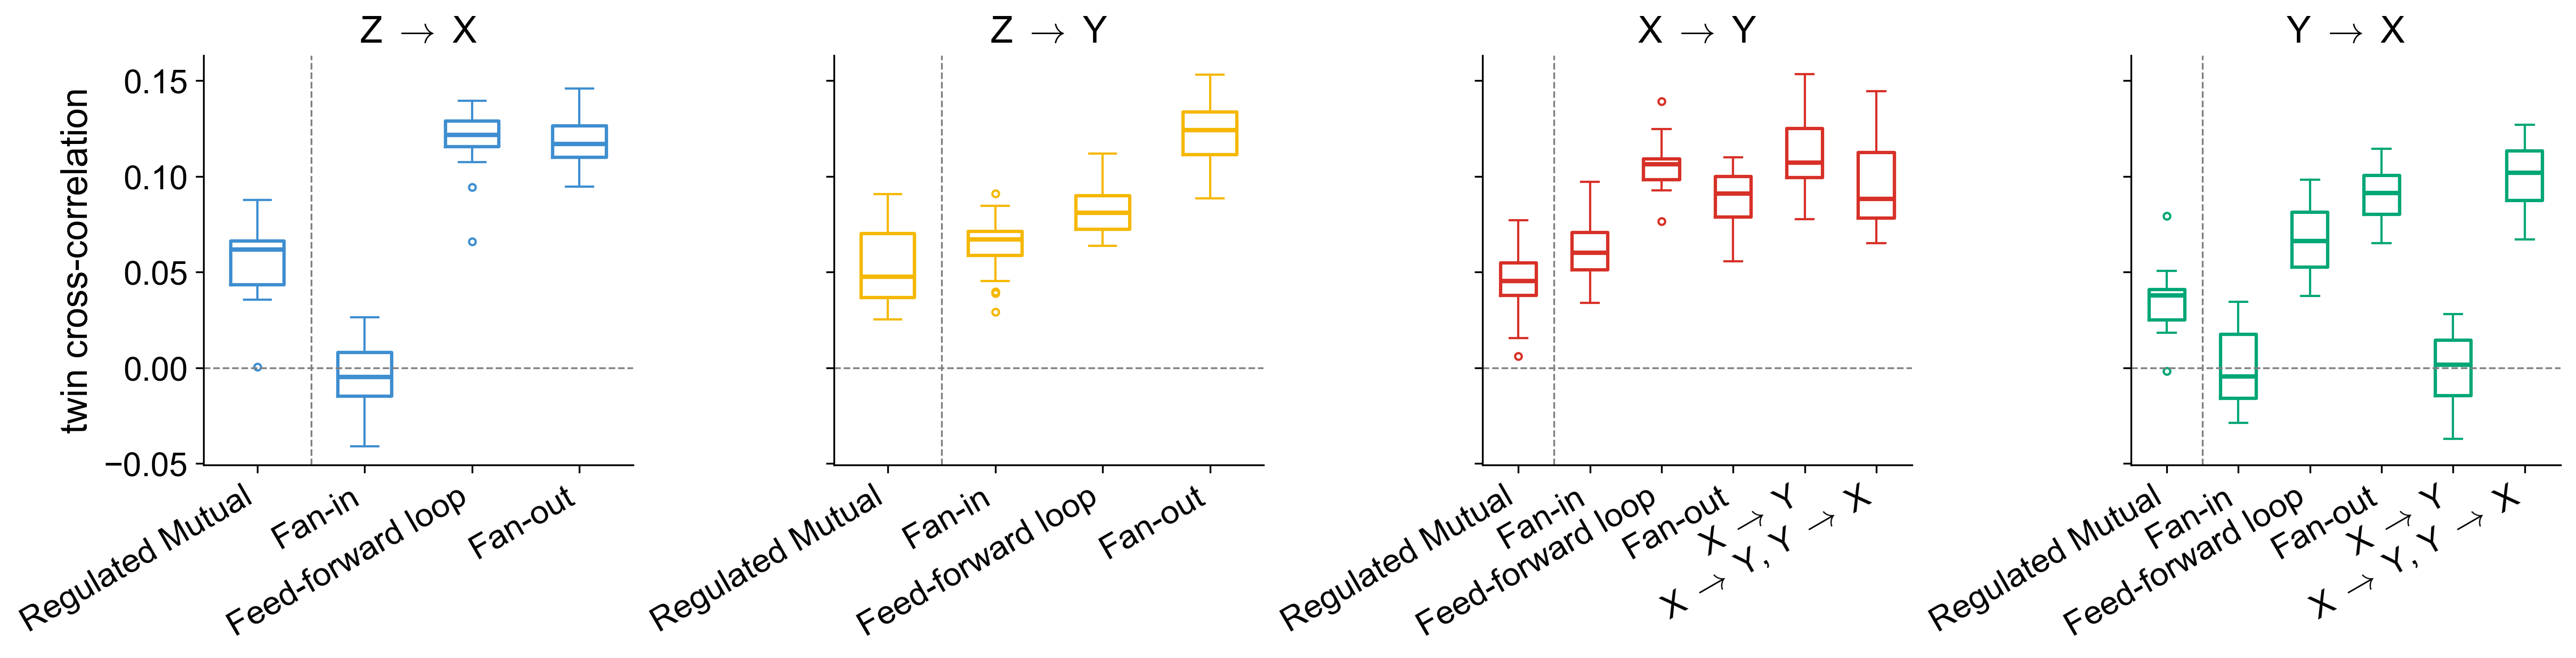

In [181]:
PAIR_COLORS = {
    "Z-X": "#3E8ED0",
    "Z-Y": "#F5B700",
    "X-Y": "#D73027",
    "Y-X": "#00A676",
}

MOTIF_DISPLAY_NAMES = {
    "A_to_B":           r"X $\rightarrow$ Y",
    "A_and_B":           r"X $\rightarrow$ Y, Y $\rightarrow$ X",
    "fan_in":           "Fan-in",
    "fan_out":          "Fan-out",
    "feed_forward":     "Feed-forward loop",
    "regulated_mutual": "Regulated Mutual",
}

# Mapping: subplot label -> (gene_pair in df_box, metric to use)
SUBPLOT_MAP = {
    "Z-X": ("Z-X", "Spearman(x_t1,y_t2)"),
    "Z-Y": ("Z-Y", "Spearman(x_t1,y_t2)"),
    "X-Y": ("X-Y", "Spearman(x_t1,y_t2)"),
    "Y-X": ("X-Y", "Spearman(y_t1,x_t2)"),  # reverse of X-Y
}

metric_forward = "Spearman(x_t1,y_t2)"

gene_pairs_all = sorted(df_box["gene_pair"].unique())
motifs         = ['regulated_mutual', 'fan_in', 'feed_forward', 'fan_out', "A_to_B", "A_and_B"]

from matplotlib.gridspec import GridSpec

motifs_4 = [m for m in motifs if m != "A_to_B"]  # 4 motifs
motifs_5 = motifs                                  # 5 motifs (includes A_to_B)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4),
    sharey=True,
    constrained_layout=True
)
LABEL_MAP = {
    "Z-X": r"Z $\rightarrow$ X",
    "Z-Y": r"Z $\rightarrow$ Y",
    "Y-X": r"Y $\rightarrow$ X",
    "X-Y": r"X $\rightarrow$ Y",
}
for ax, gp in zip(axes, ["Z-X", "Z-Y", "X-Y", "Y-X"]):

    gp_key, metric = SUBPLOT_MAP[gp]

    if gp_key not in gene_pairs_all:
        ax.set_visible(False)
        continue

    color = PAIR_COLORS.get(gp, "#333333")

    motifs_all = ['regulated_mutual','fan_in', 'feed_forward', 'fan_out', "A_to_B", "A_and_B"]
    motifs_ordered = [m for m in motifs_all if m not in ["A_to_B", "A_and_B"]] + ["A_to_B", "A_and_B"]

    if "Z" in gp:
        motifs_to_plot = [
            m for m in motifs_ordered
            if m not in ["A_to_B", "A_and_B"]
        ]
    else:
        motifs_to_plot = motifs_ordered

    n_motifs = len(motifs_to_plot)

    data_forward = [
        df_box[
            (df_box["motif"] == motif) &
            (df_box["gene_pair"] == gp_key) &
            (df_box["metric"] == metric)
        ]["value"].dropna().values
        for motif in motifs_to_plot
    ]

    bp = ax.boxplot(
        data_forward,
        widths=0.5,
        patch_artist=False,  # important
        medianprops=dict(color=color, linewidth=2),
        boxprops=dict(linewidth=1.5, color=color),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker="o",
                        markeredgecolor=color,
                        markerfacecolor="none",
                        markersize=3),
    )

    ax.set_xticks(np.arange(1, n_motifs + 1))
    ax.set_xticklabels(
        [MOTIF_DISPLAY_NAMES.get(m, m) for m in motifs_to_plot],
        rotation=30,
        ha="right"
    )
    # After the boxplot call, before set_xticks
    ax.axvline(1.5, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(LABEL_MAP[gp], color="black")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[0].set_ylabel("twin cross-correlation")
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4_motifs/"
plt.savefig(f"{path_to_plots}/cross_correlation.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/cross_correlation.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f"{path_to_plots}/cross_correlation.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.show()

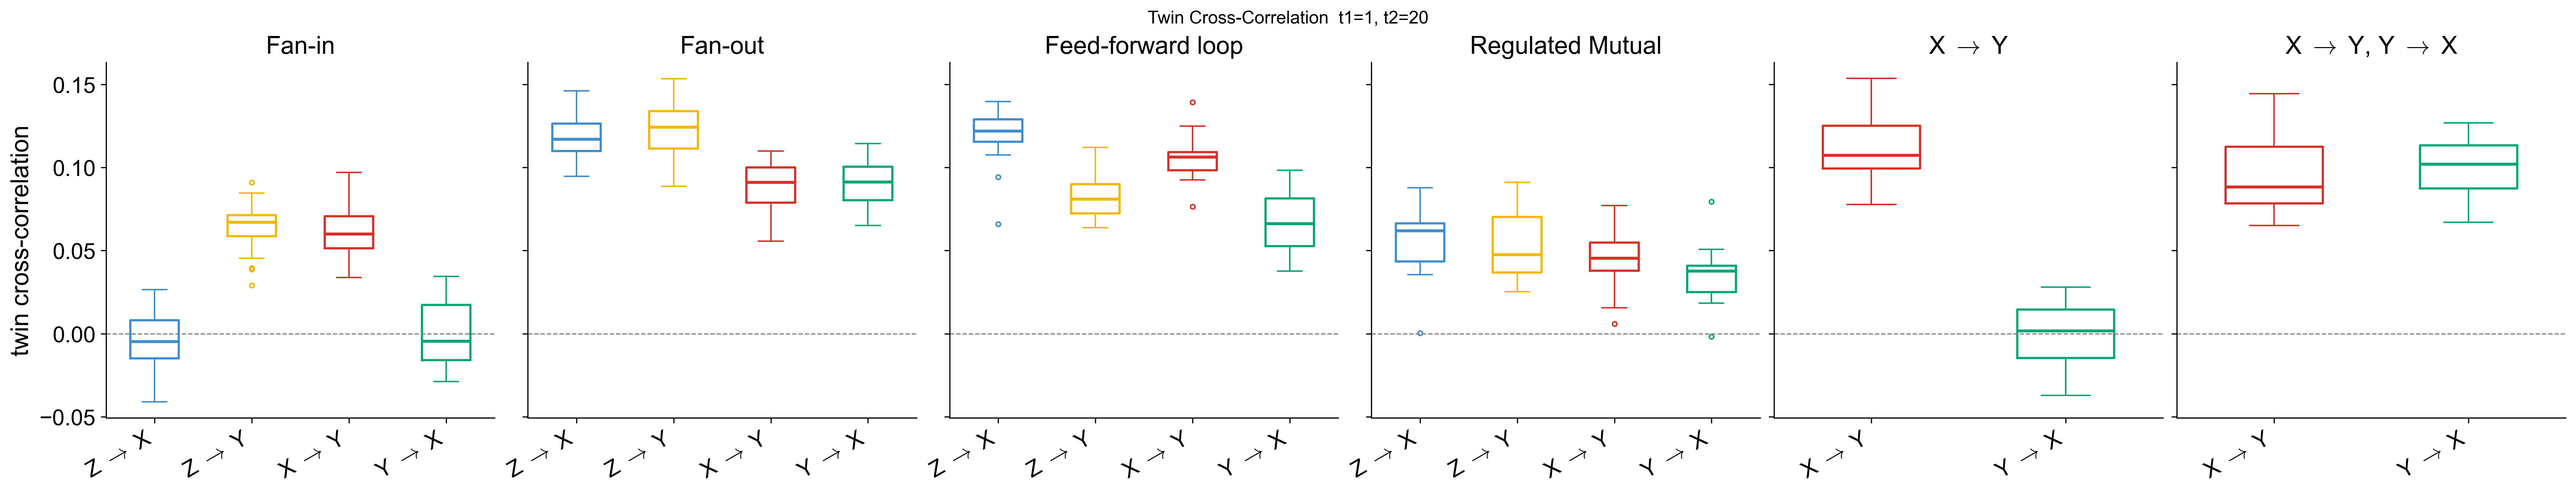

In [155]:
PAIR_COLORS = {
    "Z-X": "#3E8ED0",
    "Z-Y": "#F5B700",
    "X-Y": "#D73027",
    "Y-X": "#00A676",
}

MOTIF_DISPLAY_NAMES = {
    "A_to_B":           r"X $\rightarrow$ Y",
    "A_and_B":          r"X $\rightarrow$ Y, Y $\rightarrow$ X",
    "fan_in":           "Fan-in",
    "fan_out":          "Fan-out",
    "feed_forward":     "Feed-forward loop",
    "regulated_mutual": "Regulated Mutual",
}

SUBPLOT_MAP = {
    "Z-X": ("Z-X", "Spearman(x_t1,y_t2)"),
    "Z-Y": ("Z-Y", "Spearman(x_t1,y_t2)"),
    "X-Y": ("X-Y", "Spearman(x_t1,y_t2)"),
    "Y-X": ("X-Y", "Spearman(y_t1,x_t2)"),
}

LABEL_MAP = {
    "Z-X": r"Z $\rightarrow$ X",
    "Z-Y": r"Z $\rightarrow$ Y",
    "X-Y": r"X $\rightarrow$ Y",
    "Y-X": r"Y $\rightarrow$ X",
}

gene_pairs_all  = sorted(df_box["gene_pair"].unique())
motifs_all      = list(MOTIF_FILES.keys())
motifs_ordered  = [m for m in motifs_all if m not in ["A_to_B", "A_and_B"]] + ["A_to_B", "A_and_B"]

# Subplots: one per motif
n_motifs = len(motifs_ordered)
fig, axes = plt.subplots(1, n_motifs, figsize=(4 * n_motifs, 4.5),
                         sharey=True, constrained_layout=True)

directions = ["Z-X", "Z-Y", "X-Y", "Y-X"]

for ax, motif in zip(axes, motifs_ordered):

    # For A_to_B and A_and_B, Z pairs are not available
    if motif in ["A_to_B", "A_and_B"]:
        directions_to_plot = ["X-Y", "Y-X"]
    else:
        directions_to_plot = directions

    data_per_direction = []
    colors_per_direction = []
    labels_per_direction = []

    for gp in directions_to_plot:
        gp_key, metric = SUBPLOT_MAP[gp]
        if gp_key not in gene_pairs_all:
            continue
        vals = df_box[
            (df_box["motif"]     == motif) &
            (df_box["gene_pair"] == gp_key) &
            (df_box["metric"]    == metric)
        ]["value"].dropna().values
        data_per_direction.append(vals)
        colors_per_direction.append(PAIR_COLORS[gp])
        labels_per_direction.append(LABEL_MAP[gp])

    n_boxes = len(data_per_direction)

    bp = ax.boxplot(
        data_per_direction,
        widths=0.5,
        patch_artist=False,
        medianprops=dict(linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        flierprops=dict(marker="o", markerfacecolor="none", markersize=3),
    )

    # Apply per-box colors
    for i, (box, whisker1, whisker2, cap1, cap2, flier, median) in enumerate(zip(
        bp["boxes"],
        bp["whiskers"][0::2],
        bp["whiskers"][1::2],
        bp["caps"][0::2],
        bp["caps"][1::2],
        bp["fliers"],
        bp["medians"],
    )):
        c = colors_per_direction[i]
        box.set_color(c)
        whisker1.set_color(c)
        whisker2.set_color(c)
        cap1.set_color(c)
        cap2.set_color(c)
        flier.set_markeredgecolor(c)
        median.set_color(c)

    ax.set_xticks(np.arange(1, n_boxes + 1))
    ax.set_xticklabels(labels_per_direction, rotation=30, ha="right")
    ax.set_title(MOTIF_DISPLAY_NAMES.get(motif, motif), color="black")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[0].set_ylabel("twin cross-correlation")
plt.suptitle(f"Twin Cross-Correlation  t1={t1_fixed}, t2={t2_fixed}")
plt.show()